# Overnight Drift Strategy — Backtest

**Signal:** Buy top 10 NIFTY 50 stocks ranked by 20-session mean overnight return at 3:20 PM.
Sell next morning at 9:25 AM. Trade every session — no US filter.

**Change `STARTING_CAPITAL` in cell 1 to see results at any capital level.**

---

Three scenarios are compared:

| Scenario | Description | Tax |
|----------|-------------|-----|
| **Fixed capital** | Deploy the same starting amount every session. Profits are not reinvested. | 20% STCG on net gains |
| **Compounding** | Reinvest all profits — deploy full portfolio every session. | 20% STCG on net gains |
| **NIFTY index fund** | Buy-and-hold NIFTY 50 index fund from day 1. | 10% LTCG on gains |

---

**Charges modeled (Zerodha / AngelOne, equity delivery = CNC):**

| Charge | Rate | Applied to |
|--------|------|----------|
| STT | 0.10% | **Both buy-side and sell-side** (equity delivery — Finance Act 2004) |
| Stamp duty | 0.015% | Buy-side only |
| Exchange charge + 18% GST | 0.00297% per side | Both sides |
| IPFT + 18% GST | 0.0001% per side | Both sides |
| SEBI charge + 18% GST | 0.0001% per side | Both sides |
| Brokerage | **Rs 0** | Delivery (CNC) is free |
| DP debit charge | Rs 13 + 18% GST = Rs 15.34 per scrip sold | Sell side only |

**Total per session (10 stocks):**
- Percentage: **0.2225% of capital** (STT both sides dominates)
- Flat: **Rs 153.40** (DP charge only; brokerage is free for delivery)


In [11]:
# ═══════════════════════════════════════════════════════════════════════════════
#  CONFIGURATION  —  only change values in this cell
# ═══════════════════════════════════════════════════════════════════════════════

STARTING_CAPITAL = 2_00_000      # Rs  ← CHANGE THIS (e.g. 1_00_000 for Rs 1L)
START_DATE       = '2019-01-01'  # backtest start
END_DATE         = '2026-04-15'  # backtest end

# ── Charge parameters  (Zerodha / AngelOne, equity delivery) ─────────────────
# Percentage rates — all as fraction of deployed capital K per round-trip:
#   STT      = 0.10%  of BOTH buy-side AND sell-side value (equity delivery, Finance Act 2004)
#   Stamp    = 0.015% of buy-side value only
#   Exchange = 0.00297% per side + 18% GST, both sides
#   IPFT     = 0.001%  per side (Rs 10/crore, Investor Protection Fund Trust)
#   SEBI     = 0.0001% per side + 18% GST, both sides
STT_BUY_RATE    = 0.001_0       # 0.10%  buy-side  (equity delivery — both sides charged)
STT_SELL_RATE   = 0.001_0       # 0.10%  sell-side
STAMP_RATE      = 0.000_15      # 0.015% buy-only
EXCHANGE_RATE   = 0.000_029_7   # NSE exchange, per side
IPFT_RATE       = 0.000_001     # IPFT, per side (same magnitude as SEBI)
SEBI_RATE       = 0.000_001     # SEBI, per side
GST_EXCHANGE    = 0.18          # 18% GST on exchange + IPFT + SEBI

# Total % cost per round-trip as fraction of capital:
PCT_COST = (STT_BUY_RATE + STT_SELL_RATE + STAMP_RATE
            + 2 * (EXCHANGE_RATE + IPFT_RATE + SEBI_RATE) * (1 + GST_EXCHANGE))
# = 0.2225%  (STT buy 0.100% + STT sell 0.100% + Stamp 0.015% + Exchange/IPFT/SEBI+GST ~0.007%)

# Flat cost per session (independent of capital):
N_STOCKS     = 10
DP_PER_SCRIP = 13.0             # Rs per scrip sold (Zerodha CDSL debit: Rs 13 base)
GST_DP       = 0.18
FLAT_COST    = N_STOCKS * DP_PER_SCRIP * (1 + GST_DP)   # Rs 153.40 for 10 stocks

# ── Tax rates ──────────────────────────────────────────────────────────────────────────────
STCG_TAX  = 0.20    # 20% Short-Term Capital Gains  (strategy — held < 1 year)
LTCG_TAX  = 0.10    # 10% Long-Term Capital Gains   (NIFTY index fund)

# ── Strategy parameters ────────────────────────────────────────────────────────────────
LOOKBACK = 20       # rolling window for overnight momentum score (sessions)
TOP_N    = 10       # number of stocks to buy per active session

# ── Print cost summary ─────────────────────────────────────────────────────────────────
print(f'Starting capital : Rs {STARTING_CAPITAL:,.0f}  (Rs {STARTING_CAPITAL/1e5:.1f}L)')
print(f'Flat cost/session: Rs {FLAT_COST:,.2f}  (DP charge on {N_STOCKS} stocks @ Rs {DP_PER_SCRIP}+GST)')
print(f'Pct cost/session : {PCT_COST:.4%} of capital')
print()
print('Total cost per session at various capital levels:')
for K in [50_000, 1_00_000, 2_00_000, 3_00_000, 5_00_000, 10_00_000]:
    total = FLAT_COST + K * PCT_COST
    print(f'  Rs {K/1e5:4.1f}L : Rs {total:>6,.0f}  =  {total/K*100:.3f}% of capital')


Starting capital : Rs 200,000  (Rs 2.0L)
Flat cost/session: Rs 153.40  (DP charge on 10 stocks @ Rs 13.0+GST)
Pct cost/session : 0.2225% of capital

Total cost per session at various capital levels:
  Rs  0.5L : Rs    265  =  0.529% of capital
  Rs  1.0L : Rs    376  =  0.376% of capital
  Rs  2.0L : Rs    598  =  0.299% of capital
  Rs  3.0L : Rs    821  =  0.274% of capital
  Rs  5.0L : Rs  1,266  =  0.253% of capital
  Rs 10.0L : Rs  2,378  =  0.238% of capital


In [12]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

%matplotlib inline
plt.rcParams['figure.figsize'] = (16, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

LOOKBACK = 20      # sessions for rolling momentum score
TOP_N    = 10      # stocks to buy each active day
COST     = 0.0015  # 0.15% round-trip cost per active session

In [13]:
# ── Point-in-time NIFTY 50 constituents ──────────────────────────────────────
# Baseline: verified NIFTY 50 composition as of 2010-01-01 (50 stocks).
# All changes sourced from NSE India official rebalancing notices (2010–2026).
#
# Stocks with no/limited yfinance coverage → return NaN → excluded naturally:
#   RANBAXY.NS     — merged into Sun Pharma 2015, delisted
#   STERLITE.NS    — merged with Sesa Goa to form Vedanta 2013
#   SESAGOA.NS     — merged with Sterlite 2013
#   TATAMOTORS.NS  — demerged Oct 2025, yfinance returns 404
#   HDFC.NS        — merged into HDFCBANK Jul 2023, yfinance returns 404
#   IBULLHSGFIN.NS — delisted
#
# Note: between Apr 2016 and Sep 2017, index briefly has 51 stocks due to a
# data gap in NSE's records (TATAMTRDVR addition unmatched by equal removal).
# This does not affect the strategy — only TOP_N=10 stocks are picked each day.

BASELINE = [
    'ABB',        'ACC',        'AMBUJACEM',  'AXISBANK',   'BHARTIARTL',
    'BHEL',       'BPCL',       'CAIRN',      'CIPLA',      'DLF',
    'GAIL',       'GRASIM',     'HCLTECH',    'HDFC',       'HDFCBANK',
    'HEROMOTOCO', 'HINDALCO',   'HINDUNILVR', 'ICICIBANK',  'IDEA',
    'IDFC',       'INFY',       'ITC',        'JINDALSTEL', 'JPASSOCIAT',
    'LT',         'M&M',        'MARUTI',     'NTPC',       'ONGC',
    'PNB',        'POWERGRID',  'RANBAXY',    'RCOM',       'RELCAPITAL',
    'RELIANCE',   'RELINFRA',   'RPOWER',     'SAIL',       'SBIN',
    'SIEMENS',    'STERLITE',   'SUNPHARMA',  'SUZLON',     'TATAMOTORS',
    'TATAPOWER',  'TATASTEEL',  'TCS',        'UNITECH',    'WIPRO',
]  # 50 stocks as of Jan 1, 2010

CHANGES = [
    # ── 2010 ──────────────────────────────────────────────────────────────────
    ('2010-04-08', ['KOTAKBANK'],                          ['GRASIM']),
    ('2010-10-01', ['BAJAJ-AUTO', 'DRREDDY', 'SESAGOA'],  ['ABB', 'IDEA', 'UNITECH']),
    # ── 2011 ──────────────────────────────────────────────────────────────────
    ('2011-03-25', ['GRASIM'],                             ['SUZLON']),
    ('2011-10-10', ['COALINDIA'],                          ['RELCAPITAL']),
    # ── 2012 ──────────────────────────────────────────────────────────────────
    ('2012-04-27', ['ASIANPAINT', 'BANKBARODA'],           ['RCOM', 'RPOWER']),
    ('2012-09-28', ['LUPIN', 'ULTRACEMCO'],                ['SAIL', 'STERLITE']),
    # ── 2013: Sesa Goa + Sterlite merged → Vedanta (VEDL) ────────────────────
    ('2013-04-01', ['INDUSINDBK', 'NMDC', 'VEDL'],        ['SESAGOA', 'SIEMENS', 'WIPRO']),
    ('2013-09-27', ['WIPRO'],                              ['RELINFRA']),
    # ── 2014 ──────────────────────────────────────────────────────────────────
    ('2014-03-28', ['TECHM', 'UNITDSPR'],                  ['JPASSOCIAT', 'RANBAXY']),
    ('2014-09-19', ['ZEEL'],                               ['UNITDSPR']),
    # ── 2015 ──────────────────────────────────────────────────────────────────
    ('2015-03-27', ['IDEA', 'YESBANK'],                    ['DLF', 'JINDALSTEL']),
    ('2015-05-29', ['BOSCHLTD'],                           ['IDFC']),
    ('2015-09-28', ['ADANIPORTS'],                         ['NMDC']),
    # ── 2016: 4 added, 3 removed (index at 51 until Sep 2017) ────────────────
    ('2016-04-01', ['AUROPHARMA', 'EICHERMOT', 'INFRATEL', 'TATAMTRDVR'],
                   ['CAIRN', 'PNB', 'VEDL']),
    # ── 2017: 3 added, 4 removed (index back to 50) ──────────────────────────
    ('2017-03-31', ['IBULLHSGFIN', 'IOC'],                 ['BHEL', 'IDEA']),
    ('2017-05-26', ['VEDL'],                               ['GRASIM']),
    ('2017-09-29', ['BAJFINANCE', 'HINDPETRO', 'UPL'],
                   ['ACC', 'BANKBARODA', 'TATAMTRDVR', 'TATAPOWER']),
    # ── 2018 ──────────────────────────────────────────────────────────────────
    ('2018-04-02', ['BAJAJFINSV', 'GRASIM', 'TITAN'],     ['AMBUJACEM', 'AUROPHARMA', 'BOSCHLTD']),
    ('2018-09-28', ['JSWSTEEL'],                           ['LUPIN']),
    # ── 2019 ──────────────────────────────────────────────────────────────────
    ('2019-03-29', ['BRITANNIA'],                          ['HINDPETRO']),
    ('2019-09-27', ['NESTLEIND'],                          ['IBULLHSGFIN']),
    # ── 2020 ──────────────────────────────────────────────────────────────────
    ('2020-03-19', ['SHREECEM'],                           ['YESBANK']),
    ('2020-07-31', ['HDFCLIFE'],                           ['VEDL']),
    ('2020-09-25', ['DIVISLAB', 'SBILIFE'],                ['INFRATEL', 'ZEEL']),
    # ── 2021 ──────────────────────────────────────────────────────────────────
    ('2021-03-31', ['TATACONSUM'],                         ['GAIL']),
    # ── 2022 ──────────────────────────────────────────────────────────────────
    ('2022-03-31', ['APOLLOHOSP'],                         ['IOC']),
    ('2022-09-30', ['ADANIENT'],                           ['SHREECEM']),
    # ── 2023 ──────────────────────────────────────────────────────────────────
    ('2023-07-13', ['LTIM'],                               ['HDFC']),
    # ── 2024 ──────────────────────────────────────────────────────────────────
    ('2024-03-28', ['SHRIRAMFIN'],                         ['UPL']),
    ('2024-09-30', ['BEL', 'TRENT'],                       ['DIVISLAB', 'LTIM']),
    # ── 2025 ──────────────────────────────────────────────────────────────────
    ('2025-03-28', ['JIOFIN'],                             ['BPCL']),
    ('2025-09-29', ['ETERNAL', 'INDIGO', 'MAXHEALTH'],    ['BRITANNIA', 'HEROMOTOCO', 'INDUSINDBK']),
    ('2025-10-01', ['TMPV'],                               ['TATAMOTORS']),
]

YF_MAP = {'M&M': 'M%26M', 'BAJAJ-AUTO': 'BAJAJ-AUTO'}

def constituents_on(dt):
    dt = pd.Timestamp(dt)
    c = set(BASELINE)
    for d, add, rem in CHANGES:
        if dt >= pd.Timestamp(d):
            c.update(add); c.difference_update(rem)
    return c

def full_universe(start, end):
    u = set(BASELINE)
    for d, add, rem in CHANGES:
        if pd.Timestamp(d) <= pd.Timestamp(end): u.update(add)
        if pd.Timestamp(d) <  pd.Timestamp(start): u.difference_update(rem)
    return sorted(u)

def to_yf(sym): return YF_MAP.get(sym, sym) + '.NS'

assert len(constituents_on('2010-01-01')) == 50, f"2010 count={len(constituents_on('2010-01-01'))}"
assert len(constituents_on('2019-01-01')) == 50, f"2019 count={len(constituents_on('2019-01-01'))}"
assert len(constituents_on('2026-04-07')) == 50, f"2026 count={len(constituents_on('2026-04-07'))}"
universe = full_universe(START_DATE, END_DATE)
print(f'Universe: {len(universe)} distinct stocks across {START_DATE} to {END_DATE}')


Universe: 68 distinct stocks across 2019-01-01 to 2026-04-15


In [14]:
# ── Fetch OHLC from yfinance ─────────────────────────────────────────────────
fetch_start = (pd.Timestamp(START_DATE) - pd.Timedelta(days=45)).strftime('%Y-%m-%d')
tickers = sorted(set(to_yf(s) for s in universe))

print(f'Fetching {len(tickers)} stock tickers...')
raw = yf.download(tickers, start=fetch_start, end=END_DATE, progress=True, auto_adjust=True)

def clean(df):
    df = df.copy()
    df.columns = [c.replace('.NS','').replace('%26','&') for c in df.columns]
    return df

close = clean(raw['Close'])
open_ = clean(raw['Open'])

missing = close.columns[close.notna().mean() <= 0.05].tolist()
if missing:
    print(f'No data (404): {missing} — excluded from all rankings as NaN.')

print(f'Done. Data: {close.index[0].date()} to {close.index[-1].date()}')


Fetching 68 stock tickers...


$INFRATEL.NS: possibly delisted; no timezone found
[***                    6%                       ]  4 of 68 completed$IBULLHSGFIN.NS: possibly delisted; no timezone found
[****                   9%                       ]  6 of 68 completed$HDFC.NS: possibly delisted; no timezone found
$TATAMOTORS.NS: possibly delisted; no timezone found
[*********************100%***********************]  68 of 68 completed

4 Failed downloads:
['INFRATEL.NS', 'IBULLHSGFIN.NS', 'HDFC.NS', 'TATAMOTORS.NS']: possibly delisted; no timezone found


No data (404): ['HDFC', 'IBULLHSGFIN', 'INFRATEL', 'TATAMOTORS'] — excluded from all rankings as NaN.
Done. Data: 2018-11-19 to 2026-04-13


In [15]:
# ── Compute overnight returns and 20-session scores ───────────────────────────
# Formula: overnight_return[t] = open[t] / close[t-1] - 1
# NaN propagates naturally — no fills, no interpolation.

overnight = (open_ / close.shift(1) - 1).iloc[1:]
scores    = overnight.rolling(LOOKBACK, min_periods=LOOKBACK).mean()

first_score = scores.dropna(how='all').index[0]
eff_start   = max(pd.Timestamp(START_DATE), first_score)
eff_end     = min(pd.Timestamp(END_DATE),   overnight.index[-1])
test_idx    = overnight.index[(overnight.index >= eff_start) & (overnight.index <= eff_end)]
print(f'Backtest range: {eff_start.date()} to {eff_end.date()} ({len(test_idx)} sessions)')

Backtest range: 2019-01-01 to 2026-04-13 (1798 sessions)


In [16]:
# ── Run backtest ──────────────────────────────────────────────────────────────
# No US filter — trade every session.
# Cost per session depends on portfolio size:
#   total_cost_Rs = FLAT_COST + portfolio * PCT_COST
#   cost_as_fraction = total_cost_Rs / portfolio
#
# For fixed-capital mode: cost fraction = FLAT/STARTING_CAPITAL + PCT_COST
# For compounding mode: cost fraction shrinks as portfolio grows.
#
# The backtest stores raw gross returns (before costs).
# Costs are applied separately in the results cell for each capital model.

avail_cols = set(close.columns)
gross_ret  = {}   # gross overnight return (before any costs)

for dt in test_idx:
    prev_scores = scores[scores.index < dt]
    if prev_scores.empty: continue
    score_row = prev_scores.iloc[-1]
    pit       = {YF_MAP.get(s,s) for s in constituents_on(dt)} & avail_cols
    ret_row   = overnight.loc[dt]
    eligible  = list(pit & set(score_row.dropna().index) & set(ret_row.dropna().index))
    if len(eligible) < TOP_N: continue
    picks     = score_row[eligible].nlargest(TOP_N).index
    gross_ret[dt] = float(ret_row[picks].mean())

gross = pd.Series(gross_ret, name='gross')
active_mask = gross != 0
print(f'Sessions: {active_mask.sum()} active / {(~active_mask).sum()} skipped / {len(gross)} total')
print(f'Gross mean return on active days: {gross[active_mask].mean():+.4%}')


Sessions: 1796 active / 2 skipped / 1798 total
Gross mean return on active days: +0.2029%


---
## Results

Run cells 1–6 first, then run this cell. Change `STARTING_CAPITAL` in cell 1 and re-run all to compare scenarios.


In [17]:
# ── Apply costs and compute all three scenarios ───────────────────────────────

# ── 1. Fixed capital ──────────────────────────────────────────────────────────
# Deploy STARTING_CAPITAL every session. Profits withdrawn, never reinvested.
# Cost fraction is constant: percentage + flat/capital.
fixed_cost_frac = PCT_COST + FLAT_COST / STARTING_CAPITAL
fixed_net = gross.copy()
fixed_net[active_mask] = gross[active_mask] - fixed_cost_frac
fixed_final = STARTING_CAPITAL + STARTING_CAPITAL * float(fixed_net[active_mask].sum())

# ── 2. Compounding ────────────────────────────────────────────────────────────
# Reinvest everything. Cost fraction shrinks each session as portfolio grows.
portfolio     = float(STARTING_CAPITAL)
comp_net_rets = {}
comp_log      = []

for dt in gross.index:
    g      = float(gross.loc[dt])
    traded = (g != 0.0)
    if traded:
        cf      = PCT_COST + FLAT_COST / portfolio   # cost fraction at current portfolio
        net     = g - cf
        gain    = portfolio * net
        portfolio += gain
    else:
        cf   = 0.0
        net  = 0.0
        gain = 0.0
    comp_net_rets[dt] = net
    comp_log.append({'Date': dt.date(),
                     'Traded': 'YES' if traded else 'skip',
                     'Gross': f'{g:+.3%}' if traded else '',
                     'Cost':  f'{cf:.3%}'  if traded else '',
                     'Net':   f'{net:+.3%}' if traded else '',
                     'P&L':   f'Rs {gain:>+12,.0f}' if traded else '',
                     'Portfolio': f'Rs {portfolio:>14,.0f}'})

comp_df    = pd.DataFrame(comp_log)
comp_net   = pd.Series(comp_net_rets)
comp_final = portfolio

# ── 3. NIFTY index fund ───────────────────────────────────────────────────────
nifty  = yf.download('^NSEI', start=str(eff_start.date()), end=END_DATE,
                     progress=False)['Close'].squeeze().dropna()
ni_ret = float(nifty.iloc[-1] / nifty.iloc[0] - 1)
ni_final = STARTING_CAPITAL * (1 + ni_ret)

# ── Calendar days in backtest ─────────────────────────────────────────────────
n_cal = (gross.index[-1] - gross.index[0]).days

# ── CAGR helper ───────────────────────────────────────────────────────────────
def cagr(final, start=STARTING_CAPITAL, days=n_cal):
    if final <= 0 or start <= 0:
        return float('nan')
    return (final / start) ** (365.25 / days) - 1

# ── After-tax final values ────────────────────────────────────────────────────
# Tax is on net profit only. Losses are not taxed further.
def after_tax(final, tax_rate):
    profit = final - STARTING_CAPITAL
    if profit > 0:
        return final - profit * tax_rate
    return final   # no tax on a loss

fixed_at = after_tax(fixed_final, STCG_TAX)
comp_at  = after_tax(comp_final,  STCG_TAX)
ni_at    = after_tax(ni_final,    LTCG_TAX)

# ── Risk metrics (on active sessions only) ────────────────────────────────────
af = fixed_net[active_mask]
ac = comp_net[active_mask]
wr_fixed     = float((af > 0).mean())
wr_comp      = float((ac > 0).mean())
sharpe_fixed = af.mean() / af.std() * (252 ** 0.5)
sharpe_comp  = ac.mean() / ac.std() * (252 ** 0.5)
cum_f  = STARTING_CAPITAL * (1 + fixed_net.cumsum())
cum_c  = STARTING_CAPITAL * (1 + comp_net).cumprod()
mdd_fixed = float(((cum_f / cum_f.cummax()) - 1).min())
mdd_comp  = float(((cum_c / cum_c.cummax()) - 1).min())

# ── Break-even capital for fixed mode ─────────────────────────────────────────
# net gain = 0  =>  K * (sum_gross - N*PCT) = N * FLAT
# K_min = N * FLAT / (sum_gross - N * PCT)
N_act      = int(active_mask.sum())
sum_gross  = float(gross[active_mask].sum())
numerator  = N_act * FLAT_COST
denominator = sum_gross - N_act * PCT_COST
breakeven  = numerator / denominator if denominator > 0 else float('inf')

# ── Print ─────────────────────────────────────────────────────────────────────
def f_rs(v, w=18):
    return f'Rs {v:>13,.0f}'.rjust(w)

def f_pct(v, w=12):
    if v != v: return 'loss'.rjust(w)
    return f'{v:>+.2%}'.rjust(w)

C1 = f'Fixed Rs {STARTING_CAPITAL/1e5:.1f}L'
C2 = 'Compounding'
C3 = 'NIFTY index'

print(f'Period  : {eff_start.date()}  to  {eff_end.date()}  ({n_cal} calendar days)')
print(f'Sessions: {active_mask.sum()} active  /  {(~active_mask).sum()} skipped  /  {len(gross)} total')
print(f'Gross mean return on active days: {gross[active_mask].mean():+.4%}')
print()

print(f'Charges per session:')
print(f'  Flat (DP): Rs {FLAT_COST:,.1f}  |  Pct: {PCT_COST:.4%} of capital')
cost_here = FLAT_COST + STARTING_CAPITAL * PCT_COST
print(f'  At Rs {STARTING_CAPITAL/1e5:.1f}L: Rs {cost_here:,.0f} total  =  {cost_here/STARTING_CAPITAL:.4%} of capital per session')
if STARTING_CAPITAL < breakeven:
    print(f'  *** Fixed mode is UNPROFITABLE at Rs {STARTING_CAPITAL/1e5:.1f}L.')
    print(f'      Break-even capital for fixed mode: Rs {breakeven:,.0f}  (Rs {breakeven/1e5:.1f}L)')
    print(f'      Compounding still works — reinvestment grows past break-even quickly. ***')
else:
    print(f'  Break-even capital (fixed mode): Rs {breakeven:,.0f}  (Rs {breakeven/1e5:.1f}L)  -- you are above it.')
print()

W = 16
sep = '-' * (36 + 3*W)
print(f'  {"":34}  {C1:>{W}}  {C2:>{W}}  {C3:>{W}}')
print(f'  {sep}')
print(f'  {"Win rate (active sessions)":34}  {wr_fixed:>{W-1}.1%}  {wr_comp:>{W-1}.1%}  {"N/A":>{W}}')
print(f'  {"Sharpe ratio (active sessions)":34}  {sharpe_fixed:>{W}.2f}  {sharpe_comp:>{W}.2f}  {"N/A":>{W}}')
print(f'  {"Max drawdown":34}  {mdd_fixed:>{W-1}.2%}  {mdd_comp:>{W-1}.2%}  {"N/A":>{W}}')
print(f'  {sep}')
print(f'  {"Starting capital":34}  {f_rs(STARTING_CAPITAL)}  {f_rs(STARTING_CAPITAL)}  {f_rs(STARTING_CAPITAL)}')
print(f'  {"Final value  (pre-tax)":34}  {f_rs(fixed_final)}  {f_rs(comp_final)}  {f_rs(ni_final)}')
print(f'  {"CAGR         (pre-tax)":34}  {f_pct(cagr(fixed_final))}  {f_pct(cagr(comp_final))}  {f_pct(cagr(ni_final))}')
print(f'  {sep}')
print(f'  {"Tax":34}  {"20% STCG":>{W}}  {"20% STCG":>{W}}  {"10% LTCG":>{W}}')
print(f'  {"Final value  (after tax)":34}  {f_rs(fixed_at)}  {f_rs(comp_at)}  {f_rs(ni_at)}')
print(f'  {"CAGR         (after tax)":34}  {f_pct(cagr(fixed_at))}  {f_pct(cagr(comp_at))}  {f_pct(cagr(ni_at))}')
print(f'  {sep}')
print(f'  {"Extra vs NIFTY (after tax, Rs)":34}  {f_rs(fixed_at - ni_at)}  {f_rs(comp_at - ni_at)}  {"baseline":>{W}}')
print(f'  {"Extra vs NIFTY (CAGR pts)":34}  {f_pct(cagr(fixed_at)-cagr(ni_at))}  {f_pct(cagr(comp_at)-cagr(ni_at))}  {"baseline":>{W}}')


Period  : 2019-01-01  to  2026-04-13  (2659 calendar days)
Sessions: 1796 active  /  2 skipped  /  1798 total
Gross mean return on active days: +0.2029%

Charges per session:
  Flat (DP): Rs 153.4  |  Pct: 0.2225% of capital
  At Rs 2.0L: Rs 598 total  =  0.2992% of capital per session
  *** Fixed mode is UNPROFITABLE at Rs 2.0L.
      Break-even capital for fixed mode: Rs inf  (Rs infL)
      Compounding still works — reinvestment grows past break-even quickly. ***

                                         Fixed Rs 2.0L       Compounding       NIFTY index
  ------------------------------------------------------------------------------------
  Win rate (active sessions)                    42.4%            49.3%               N/A
  Sharpe ratio (active sessions)                 -2.11              0.10               N/A
  Max drawdown                               -172.88%         -135.83%               N/A
  -------------------------------------------------------------------------------

In [18]:
# ── Year-by-year breakdown ────────────────────────────────────────────────────
# Fixed ann. return  = gain that year / STARTING_CAPITAL  (% on deployed capital)
# Comp  ann. return  = end-of-year portfolio / start-of-year portfolio - 1
# Win rate (fixed)   = sessions where gross > fixed_cost_frac  (constant threshold)
# Win rate (comp)    = sessions where gross > PCT_COST + FLAT/portfolio (shrinking threshold)

print(f'  {"Year":<5}  {"Sessions":>9}  {"WR(fixed)":>9}  {"WR(comp)":>8}  '
      f'{"Fixed end val":>15}  {"Fixed ann":>10}  '
      f'{"Comp end val":>15}  {"Comp ann":>10}')
print(f'  {"-"*92}')

yr_fixed_running = float(STARTING_CAPITAL)
yr_comp_running  = float(STARTING_CAPITAL)

for yr in sorted(gross.index.year.unique()):
    yr_gross = gross[gross.index.year == yr]
    yr_act   = yr_gross[yr_gross != 0]
    if len(yr_act) < 3:
        continue

    # Fixed: gain = STARTING_CAPITAL * sum(net returns this year)
    yr_net_f  = yr_act - fixed_cost_frac
    yr_gain_f = STARTING_CAPITAL * float(yr_net_f.sum())
    yr_fixed_running += yr_gain_f
    yr_fixed_ann = yr_gain_f / STARTING_CAPITAL

    # Compounding: iterate sessions, cost fraction updates each session
    yr_comp_start   = yr_comp_running
    yr_comp_wins    = 0
    yr_comp_traded  = 0
    for dt, g in yr_gross.items():
        if g == 0.0:
            continue
        cf = PCT_COST + FLAT_COST / yr_comp_running
        yr_comp_wins   += int(g > cf)
        yr_comp_traded += 1
        yr_comp_running *= (1 + g - cf)
    yr_comp_ann = yr_comp_running / yr_comp_start - 1
    yr_comp_wr  = yr_comp_wins / yr_comp_traded if yr_comp_traded else float('nan')

    wr_yr_fixed = float((yr_act > fixed_cost_frac).mean())

    print(f'  {yr:<5}  {len(yr_act):>9}  {wr_yr_fixed:>9.1%}  {yr_comp_wr:>8.1%}  '
          f'Rs {yr_fixed_running:>12,.0f}  {yr_fixed_ann:>+9.1%}  '
          f'Rs {yr_comp_running:>12,.0f}  {yr_comp_ann:>+9.1%}')

print(f'  {"-"*92}')
print(f'  {"TOTAL":<5}  {active_mask.sum():>9}  {wr_fixed:>9.1%}  {wr_comp:>8.1%}  '
      f'Rs {fixed_final:>12,.0f}  {"":>10}  Rs {comp_final:>12,.0f}')
print()
print(f'  Note: WR(fixed) uses constant cost threshold ({fixed_cost_frac:.4%}/session).')
print(f'        WR(comp)  uses a shrinking threshold as portfolio grows — so it is higher.')

if fixed_final < STARTING_CAPITAL:
    print()
    pct_lost = (STARTING_CAPITAL - fixed_final) / STARTING_CAPITAL
    print(f'  Fixed mode lost {pct_lost:.1%} of capital — flat charges exceed the edge at Rs {STARTING_CAPITAL/1e5:.1f}L.')
    print(f'  Break-even capital for fixed mode: Rs {breakeven:,.0f}  (Rs {breakeven/1e5:.1f}L).')
    print(f'  Switch to compounding, or increase capital above Rs {breakeven/1e5:.1f}L.')


  Year    Sessions  WR(fixed)  WR(comp)    Fixed end val   Fixed ann     Comp end val    Comp ann
  --------------------------------------------------------------------------------------------
  2019         243      36.6%     35.0%  Rs      131,039     -34.5%  Rs      136,102     -31.9%
  2020         251      56.2%     50.6%  Rs      115,475      -7.8%  Rs      104,646     -23.1%
  2021         248      54.8%     46.8%  Rs      113,846      -0.8%  Rs       84,889     -18.9%
  2022         248      41.5%     27.8%  Rs       32,099     -40.9%  Rs       33,226     -60.9%
  2023         245      39.2%     17.1%  Rs       -6,209     -19.2%  Rs       -6,245    -118.8%
  2024         246      45.5%     91.1%  Rs      -23,354      -8.6%  Rs      -43,459    +596.0%
  2025         248      26.2%     75.8%  Rs     -110,607     -43.6%  Rs      -68,026     +56.5%
  2026          67      28.4%     52.2%  Rs     -145,966     -17.7%  Rs      -69,331      +1.9%
  -------------------------------------

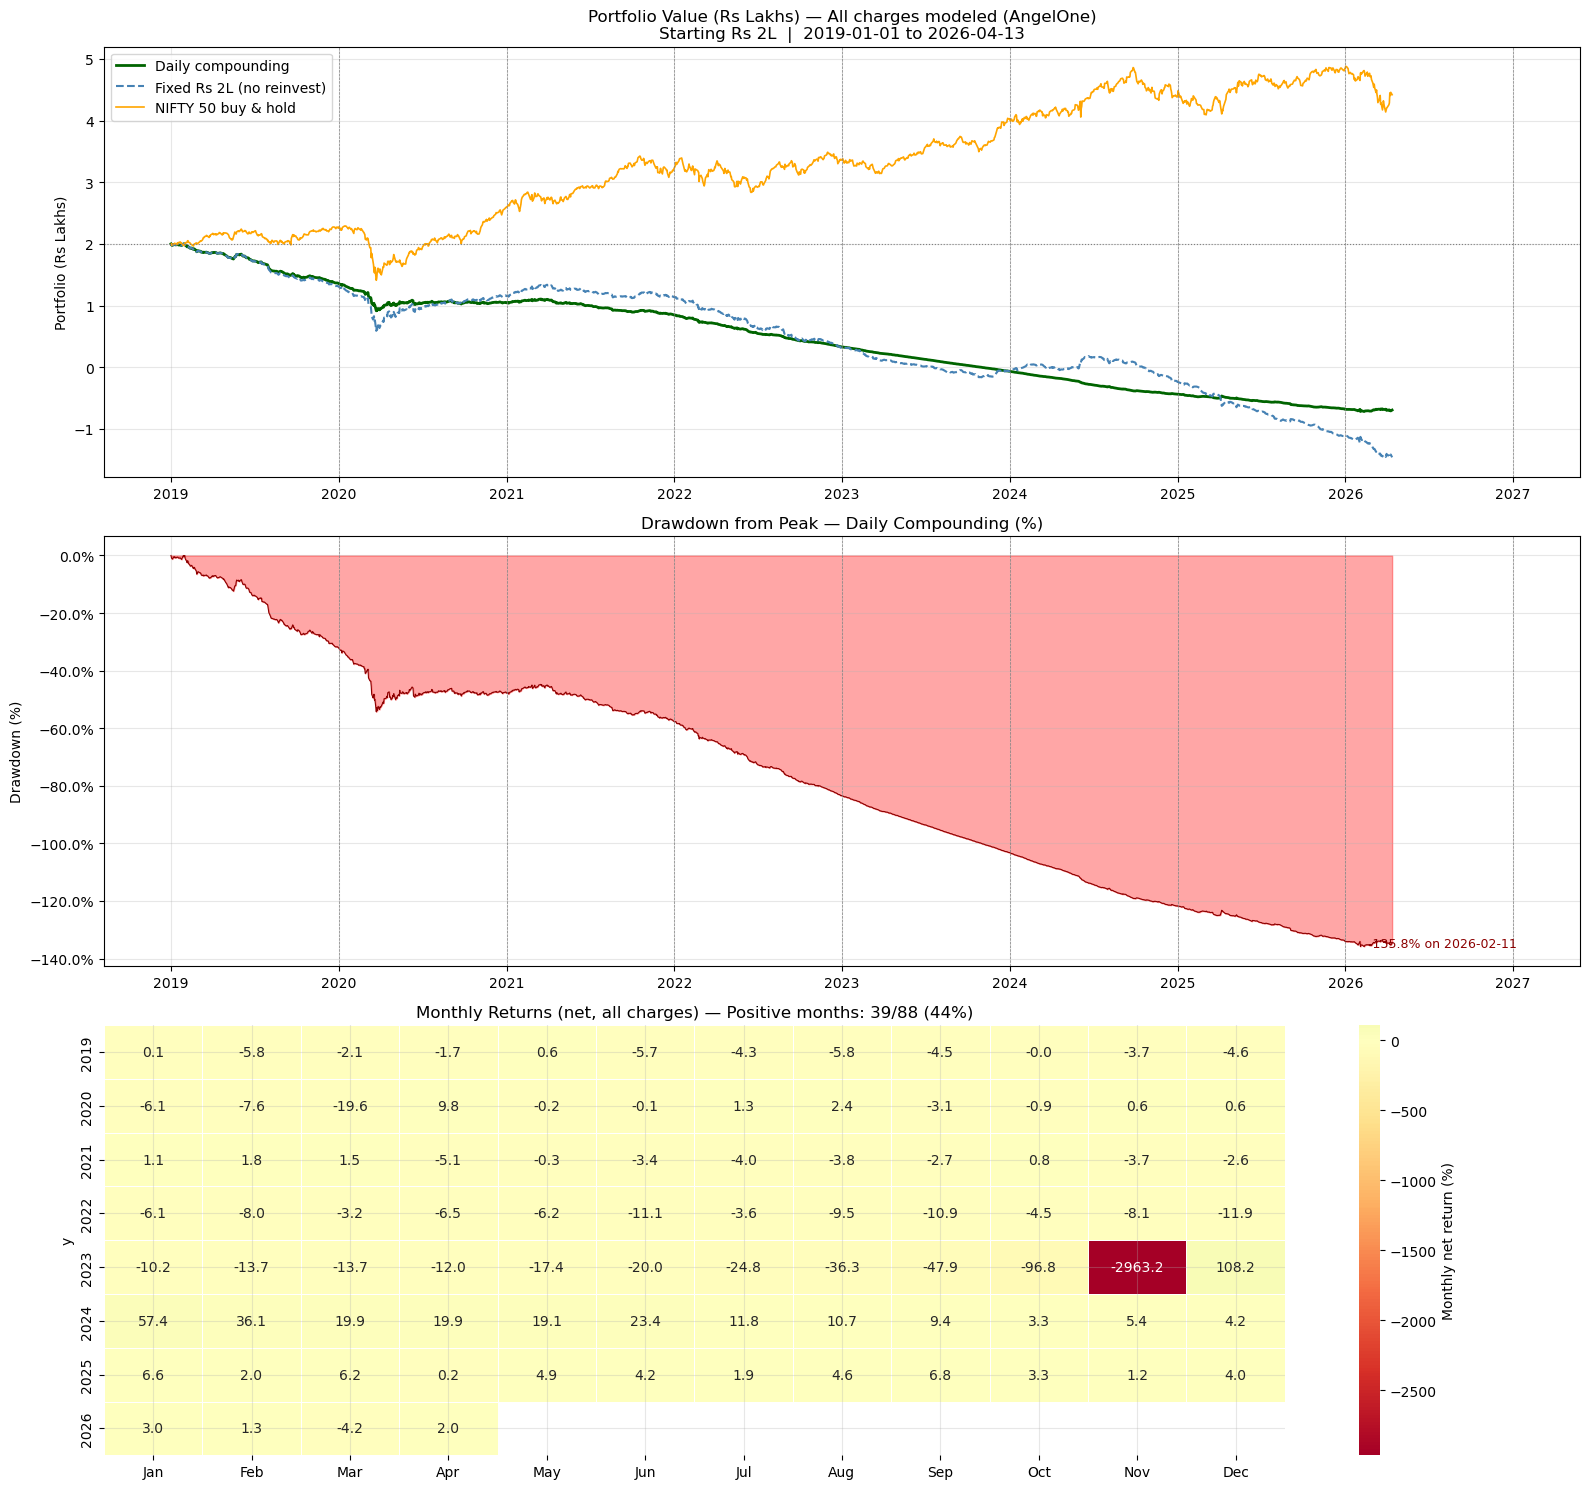

In [19]:
# ── Charts ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 15))

# ── Portfolio value ──────────────────────────────────────────────────────────
ax = axes[0]
fixed_curve = STARTING_CAPITAL + STARTING_CAPITAL * fixed_net.cumsum()
comp_curve  = STARTING_CAPITAL * (1 + comp_net).cumprod()
ni_curve    = (STARTING_CAPITAL * (nifty / nifty.iloc[0])).reindex(gross.index, method='ffill')

ax.plot(comp_curve.index,  comp_curve/1e5,  color='darkgreen', linewidth=2.0, label='Daily compounding')
ax.plot(fixed_curve.index, fixed_curve/1e5, color='steelblue', linewidth=1.5, label=f'Fixed Rs {STARTING_CAPITAL/1e5:.0f}L (no reinvest)', linestyle='--')
ax.plot(ni_curve.index,    ni_curve/1e5,    color='orange',    linewidth=1.2, label='NIFTY 50 buy & hold')
ax.axhline(STARTING_CAPITAL/1e5, color='grey', linewidth=0.8, linestyle=':')
ax.set_title(f'Portfolio Value (Rs Lakhs) — All charges modeled (AngelOne)\nStarting Rs {STARTING_CAPITAL/1e5:.0f}L  |  {eff_start.date()} to {eff_end.date()}')
ax.set_ylabel('Portfolio (Rs Lakhs)')
ax.legend()
for yr in range(eff_start.year+1, eff_end.year+2):
    ax.axvline(pd.Timestamp(f'{yr}-01-01'), color='grey', linewidth=0.5, linestyle='--')

# ── Drawdown ─────────────────────────────────────────────────────────────────
ax = axes[1]
cum = (1 + comp_net).cumprod()
dd  = (cum / cum.cummax() - 1) * 100
ax.fill_between(dd.index, dd, 0, color='red', alpha=0.35)
ax.plot(dd.index, dd, color='darkred', linewidth=0.8)
worst = dd.idxmin()
ax.annotate(f' {dd.min():.1f}% on {worst.date()}', xy=(worst, dd.min()), fontsize=9, color='darkred')
ax.set_title('Drawdown from Peak — Daily Compounding (%)')
ax.set_ylabel('Drawdown (%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
for yr in range(eff_start.year+1, eff_end.year+2):
    ax.axvline(pd.Timestamp(f'{yr}-01-01'), color='grey', linewidth=0.5, linestyle='--')

# ── Monthly heatmap ───────────────────────────────────────────────────────────
ax = axes[2]
mo   = comp_net.resample('ME').apply(lambda x: (1+x).prod()-1)
piv  = mo.to_frame('r')
piv['y'] = piv.index.year; piv['m'] = piv.index.month
heat = piv.pivot(index='y', columns='m', values='r')
mnames = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
heat.columns = [mnames[m-1] for m in heat.columns]
sns.heatmap(heat*100, cmap='RdYlGn', center=0, annot=True, fmt='.1f',
            linewidths=0.4, ax=ax, cbar_kws={'label':'Monthly net return (%)'})
pos = int((heat>0).sum().sum()); tot_mo = int(heat.notna().sum().sum())
ax.set_title(f'Monthly Returns (net, all charges) — Positive months: {pos}/{tot_mo} ({pos/tot_mo:.0%})')

plt.tight_layout()
plt.show()


In [20]:
# ── Session-by-session detail ─────────────────────────────────────────────────
# comp_df shows: gross return, cost %, net return, day P&L, running portfolio
# All charges (brokerage, DP, STT, stamp, exchange, SEBI, GST) included.
print('Full session log (daily compounding, all charges):')
pd.set_option('display.max_colwidth', 20)
pd.set_option('display.max_rows', 30)
display(comp_df.set_index('Date'))
print(f'\nTotal rows: {len(comp_df)}')
print('Filter: comp_df[comp_df.Traded=="YES"]  or  comp_df[comp_df.Date.apply(lambda d: d.year)==2024]')


Full session log (daily compounding, all charges):


,Traded,Gross,Cost,Net,P&L,Portfolio
Date,,,,,,
2019-01-01,YES,+0.307%,0.299%,+0.007%,Rs +15,"Rs 200,015"
2019-01-02,YES,-0.511%,0.299%,-0.810%,"Rs -1,620","Rs 198,394"
2019-01-03,YES,+0.006%,0.300%,-0.294%,Rs -584,"Rs 197,811"
2019-01-04,YES,+0.159%,0.300%,-0.141%,Rs -278,"Rs 197,533"
2019-01-07,YES,+1.075%,0.300%,+0.775%,"Rs +1,531","Rs 199,064"
...,...,...,...,...,...,...
2026-04-07,YES,-0.645%,0.002%,-0.647%,Rs +449,"Rs -69,040"
2026-04-08,YES,+2.041%,0.000%,+2.041%,"Rs -1,409","Rs -70,449"
2026-04-09,YES,-0.327%,0.005%,-0.332%,Rs +234,"Rs -70,215"



Total rows: 1798
Filter: comp_df[comp_df.Traded=="YES"]  or  comp_df[comp_df.Date.apply(lambda d: d.year)==2024]
